# Exploratory Data Analysis (EDA)

In this section we explore the structure of the dataset,
check data types, missing values, and basic statistics.

In [14]:
import pandas as pd

df = pd.read_csv("../data/products.csv")

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (35311, 8)


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


In [16]:
df["Category Label"].value_counts()

Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64

In [17]:
df.isnull().sum()

product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

## Cleaning Category Labels

We noticed inconsistencies in category names 
(e.g., "CPU" vs "CPUs", "Mobile Phone" vs "Mobile Phones").

We standardize category labels to avoid duplicate classes.

In [18]:
df["Category Label"] = df["Category Label"].str.strip()

df["Category Label"] = df["Category Label"].replace({
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridges"
})

In [19]:
df["Category Label"].value_counts()

Category Label
Fridge Freezers     5495
Mobile Phones       4075
Washing Machines    4036
CPUs                3855
Fridges             3580
TVs                 3564
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
Name: count, dtype: int64

## Preparing Data for Machine Learning

We use Product Title as input feature (X) 
and Category Label as target variable (y).

We split the dataset into training and test sets (80/20).

In [20]:
df = df.dropna(subset=["Product Title", "Category Label"])

In [21]:
X = df["Product Title"]
y = df["Category Label"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print(len(X_train), len(X_test))
print(y_train.value_counts().head())

28076 7020
Category Label
Fridge Freezers     4376
Mobile Phones       3245
Washing Machines    3212
CPUs                3065
Fridges             2847
Name: count, dtype: int64


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9599715099715099
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.93      0.97      0.95       681
        Freezers       0.99      0.93      0.96       440
 Fridge Freezers       0.96      0.93      0.94      1094
         Fridges       0.89      0.91      0.90       712
      Microwaves       0.99      0.94      0.97       466
   Mobile Phones       0.97      0.99      0.98       812
             TVs       0.97      0.99      0.98       708
Washing Machines       0.94      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



## Model Evaluation

We trained a Logistic Regression model using TF-IDF on Product Title.

The model achieved approximately 96% accuracy on the test set,
indicating that product titles contain strong signals for category prediction.

In [25]:
import joblib

joblib.dump(pipeline, "../model/product_category_model.pkl")

['../model/product_category_model.pkl']

<Figure size 1000x1000 with 0 Axes>

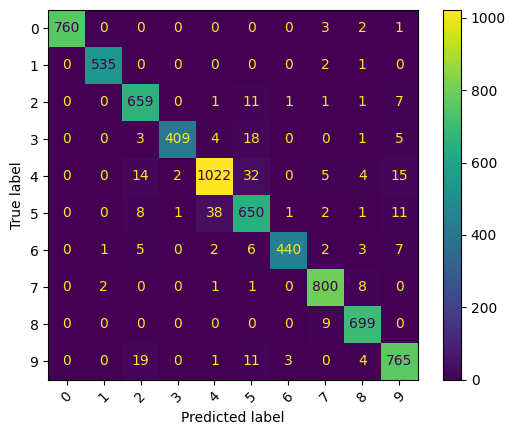

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=45)
plt.show()